# Load data

In [1]:
import os
import numpy as np
import pandas as pd

In [2]:
files = []
for dirname, dirnames, filenames in os.walk('..\IMS2013-2024'):
    if 'lemmatized' not in dirname and 'Эксперимент' not in dirname:
        for filename in filenames:
            if 'Abstract' not in filename and 'KW' not in filename and 'Anstract' not in filename and '_rus' in filename:
                files.append(os.path.join(dirname, filename))
len(files)

190

In [3]:
texts = []
for filename in files:
    with open(filename, 'r', encoding='utf-8') as f:
        texts.append(f.read())

In [4]:
df = pd.DataFrame(zip(files, texts), columns=['filepath', 'raw_text'])

# ruts

In [5]:
from ruts import ReadabilityStats
df['ruts_stats'] = df.raw_text.apply(lambda x: ReadabilityStats(x).get_stats())
for k in df.ruts_stats.values[0]:
    df[f'ruts_{k}'] = df.ruts_stats.apply(lambda x: x.get(k))
df.drop('ruts_stats', axis=1, inplace=True)

In [ ]:
from ruts import DiversityStats
df['ruts_stats'] = df.raw_text.apply(lambda x: DiversityStats(x).get_stats())
for k in df.ruts_stats.values[0]:
    df[f'ruts_{k}'] = df.ruts_stats.apply(lambda x: x.get(k))
df.drop('ruts_stats', axis=1, inplace=True)

# textstat

In [ ]:
from textstat import textstat

In [ ]:
textstat.set_lang('ru_RU')

In [ ]:
df['textstat_flesch_kincaid_grade'] = df.raw_text.apply(lambda x: textstat.flesch_kincaid_grade(x))
df['textstat_smog_index'] = df.raw_text.apply(lambda x: textstat.smog_index(x))
df['textstat_automated_readability_index'] = df.raw_text.apply(lambda x: textstat.automated_readability_index(x))
df['textstat_coleman_liau_index'] = df.raw_text.apply(lambda x: textstat.coleman_liau_index(x))
df['textstat_linsear_write_formula'] = df.raw_text.apply(lambda x: textstat.linsear_write_formula(x))
df['textstat_dale_chall_readability_score'] = df.raw_text.apply(lambda x: textstat.dale_chall_readability_score(x))

# correlation

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
corr = df.corr()

C:\Users\Андрей\AppData\Local\Temp\ipykernel_7688\658818363.py:1: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  corr = df.corr()


In [ ]:
mask = np.triu(np.ones_like(corr, dtype=bool))

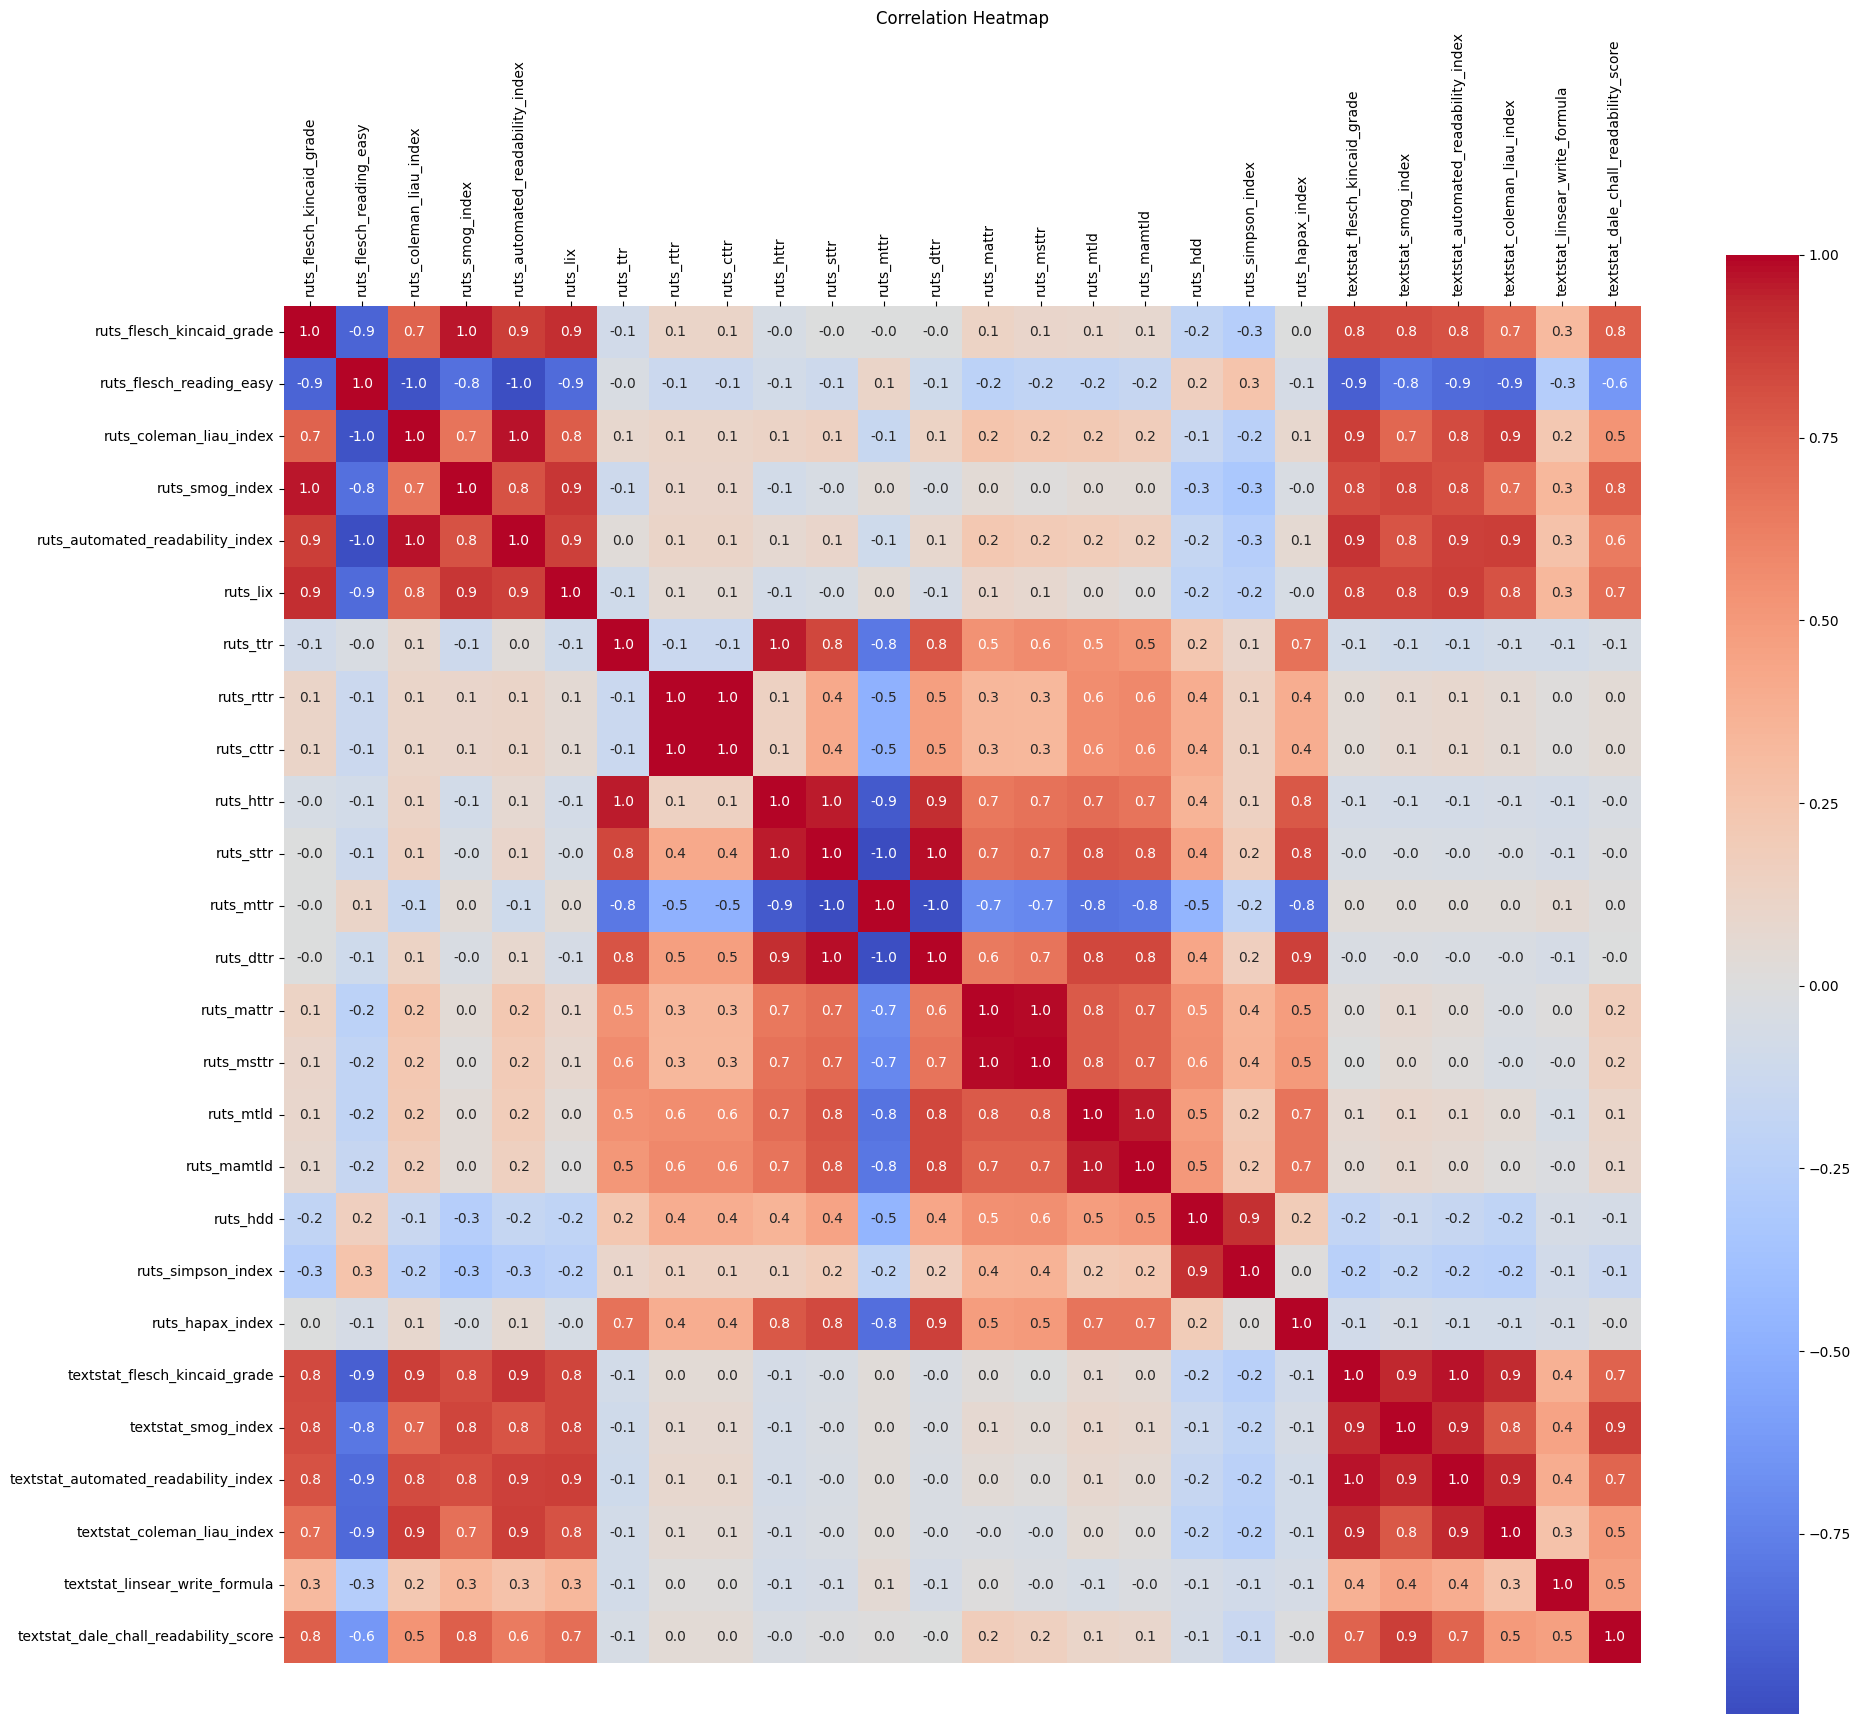

In [ ]:
plt.figure(figsize=(20, 20))
ax = sns.heatmap(corr, annot=True, fmt=".1f", cmap='coolwarm', square=True, cbar_kws={"shrink": .8}, mask=mask)
ax.xaxis.set_ticks_position('top')
ax.xaxis.set_label_position('top')
plt.xticks(rotation=90)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()